In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.tree import DecisionTreeClassifier,plot_tree,DecisionTreeRegressor

In [12]:
Boston = pd.read_csv(r'../../Datasets/Boston.csv')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [13]:
X=Boston.drop("medv",axis=1)
y=Boston['medv']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=26)

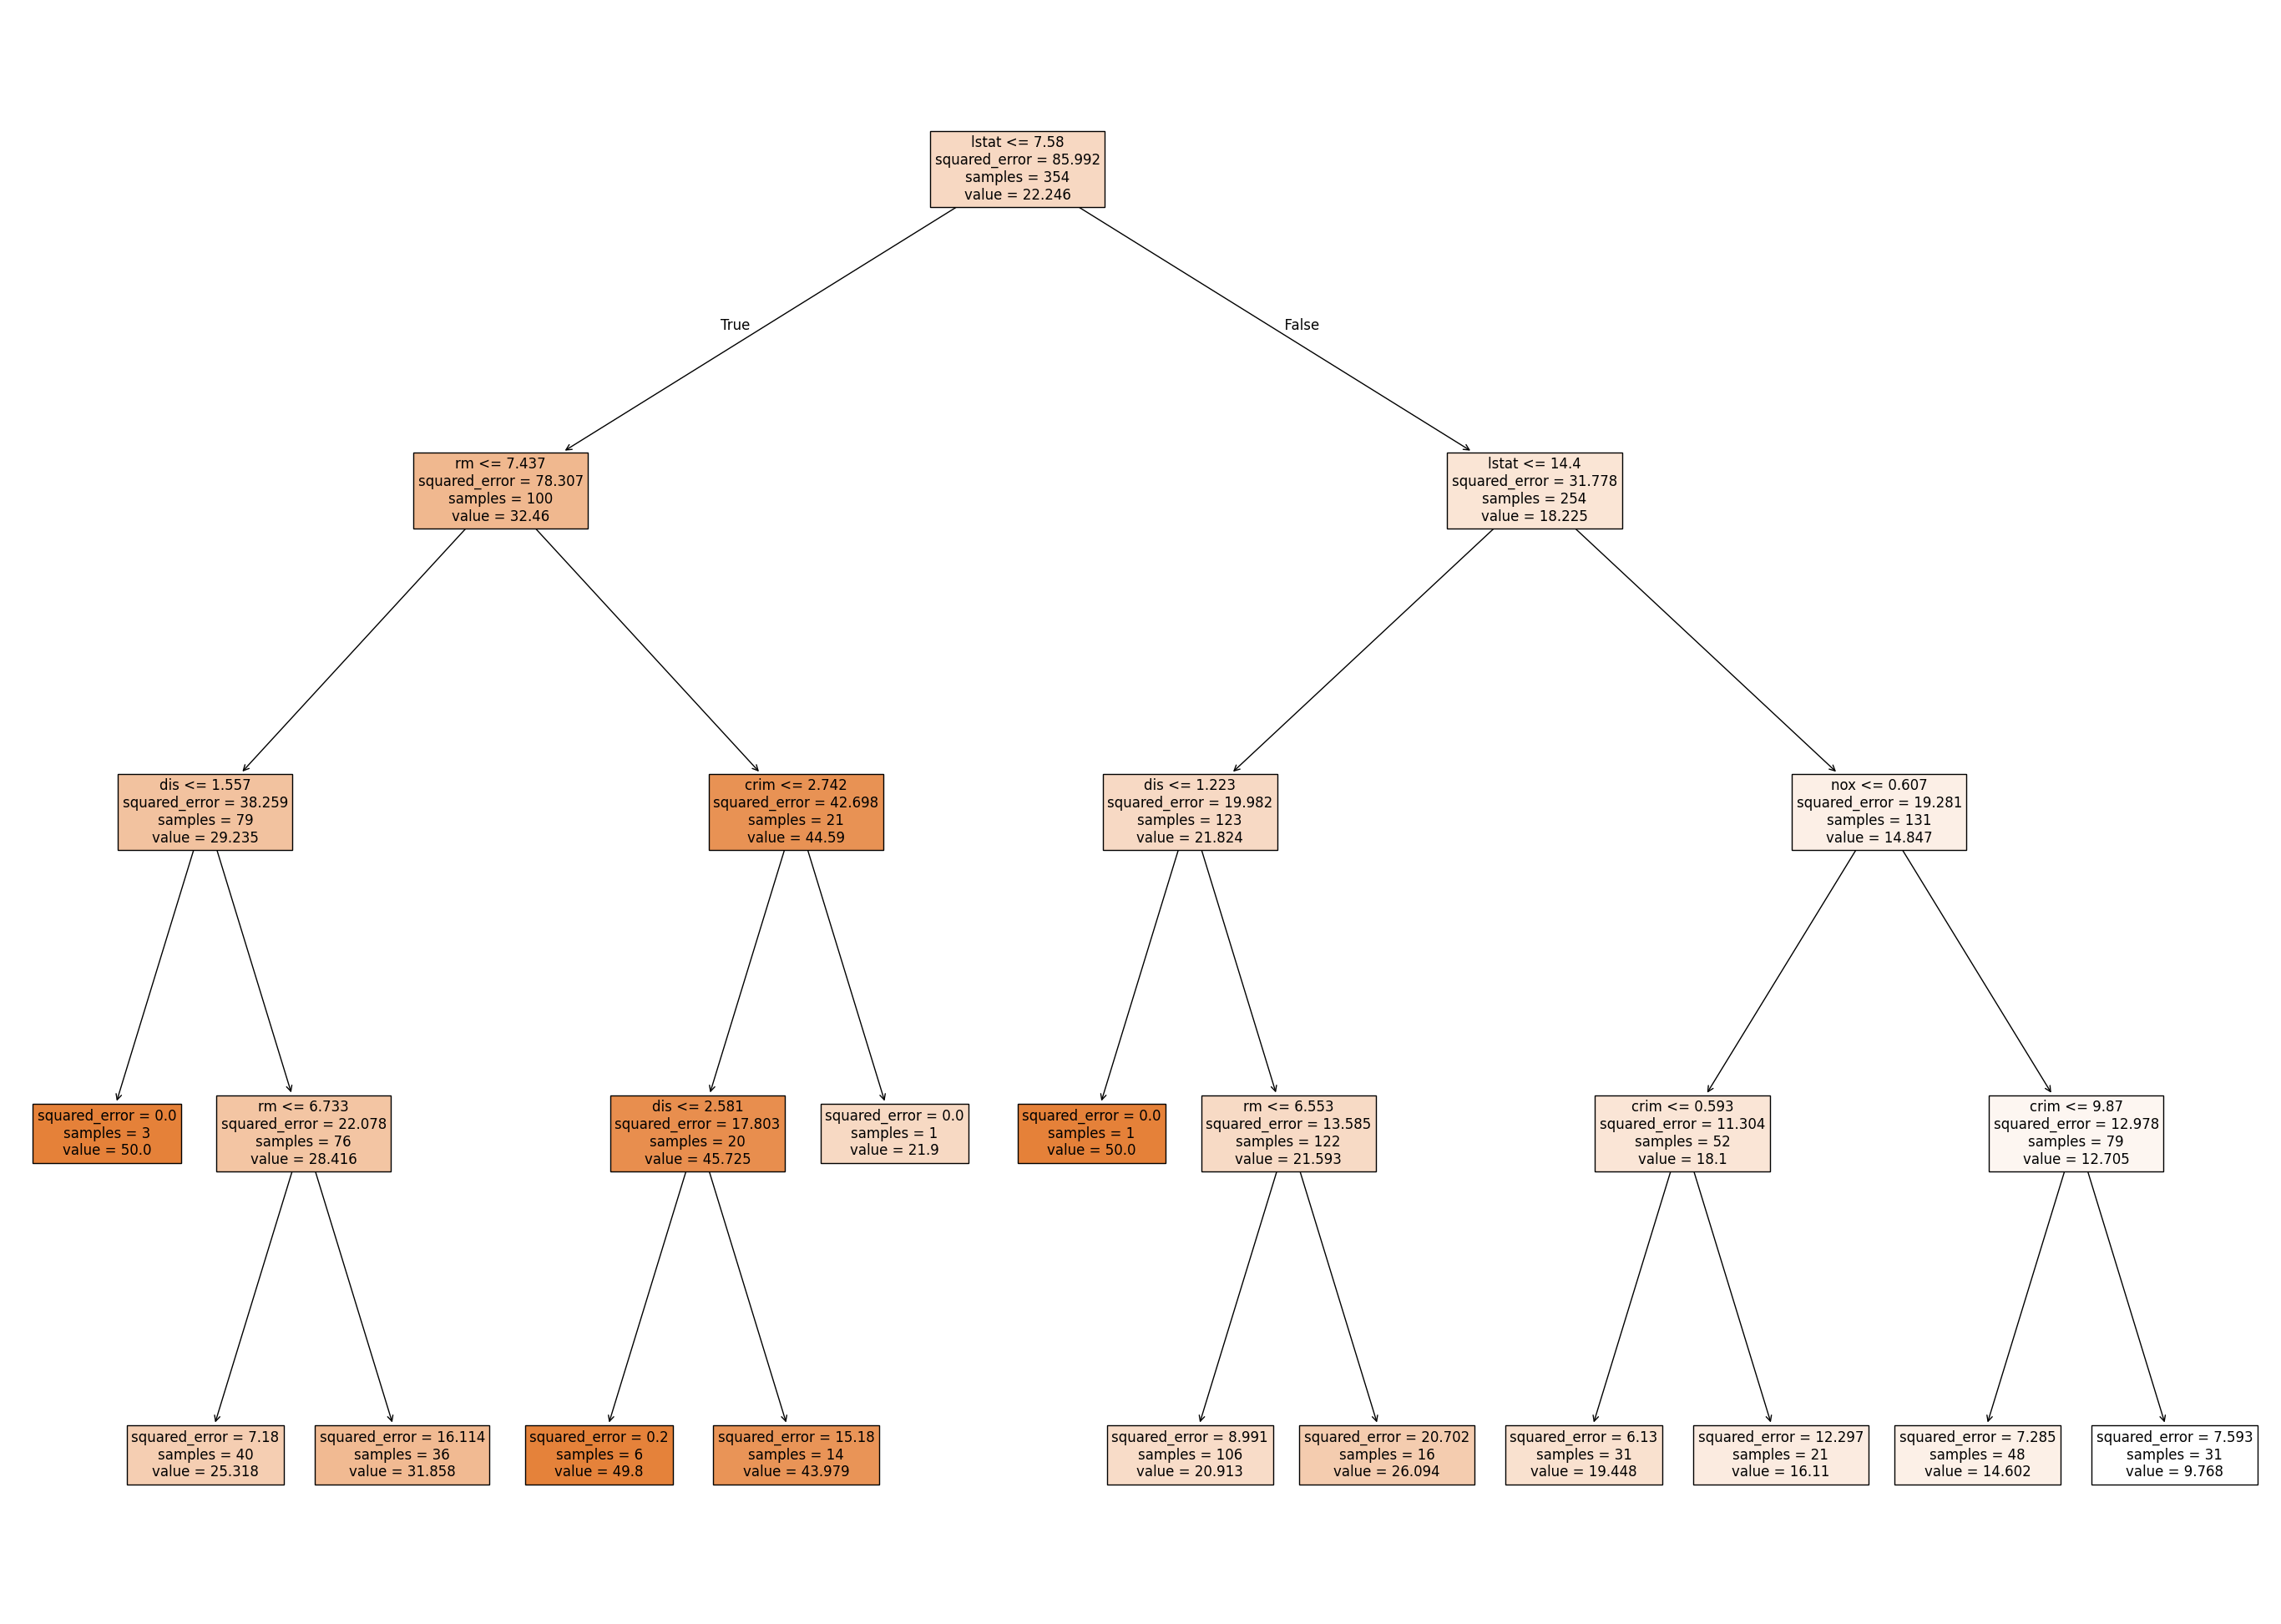

In [18]:
dtc = DecisionTreeRegressor(random_state=26,max_depth=4)
dtc.fit(X_train, y_train)

plt.figure(figsize=(35, 25))
plot_tree(dtc, 
          feature_names=list(X.columns), 
          filled=True, 
          fontsize=12)

plt.show()

In [20]:
depths=[1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves = [1,4,8,10,20,30,50,100]
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc=DecisionTreeRegressor(random_state=26,max_depth=d,min_samples_split=s,min_samples_leaf=l)
            dtc.fit(X_train,y_train)
            y_pred=dtc.predict(X_test)
            scores.append([d,s,l,r2_score(y_test,y_pred)])


df_scores = pd.DataFrame(scores, columns=['depths', 'splits', 'leaves',  'r2_score'])
df_scores.sort_values('r2_score',ascending=False).head()

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

 20%|████████████████▊                                                                   | 1/5 [00:00<00:00,  4.37it/s]

 40%|█████████████████████████████████▌                                                  | 2/5 [00:00<00:00,  4.20it/s]

 60%|██████████████████████████████████████████████████▍                                 | 3/5 [00:00<00:00,  3.94it/s]

 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [00:01<00:00,  3.77it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.70it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.82it/s]

,depths,splits,leaves,r2_score
200,5.0,4,1,0.840638
192,5.0,2,1,0.840638
216,5.0,10,1,0.839735
208,5.0,8,1,0.839735
232,5.0,30,1,0.835667


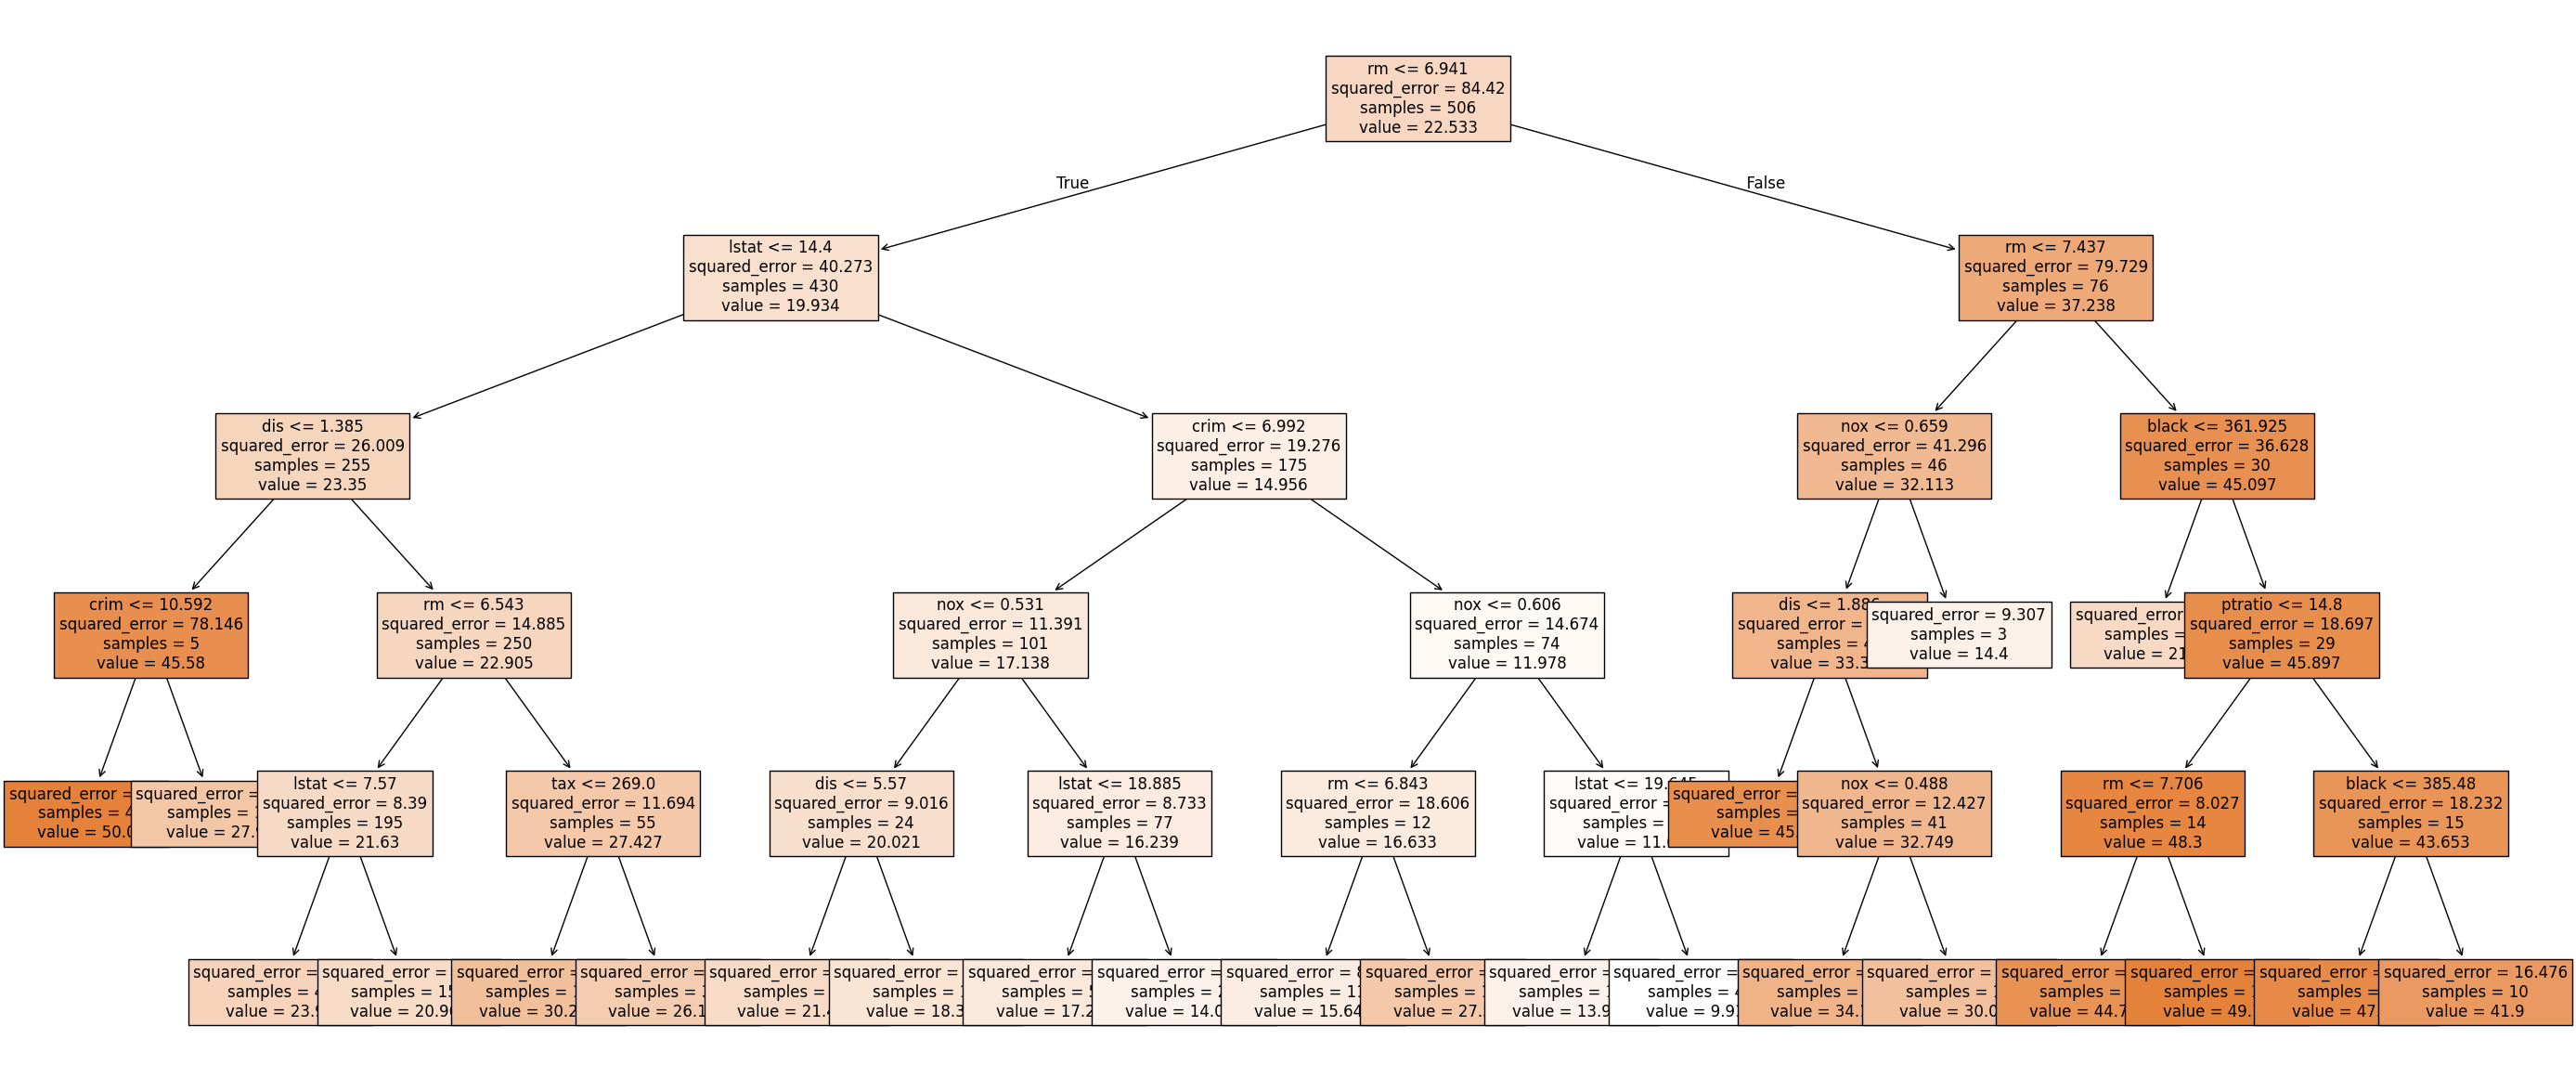

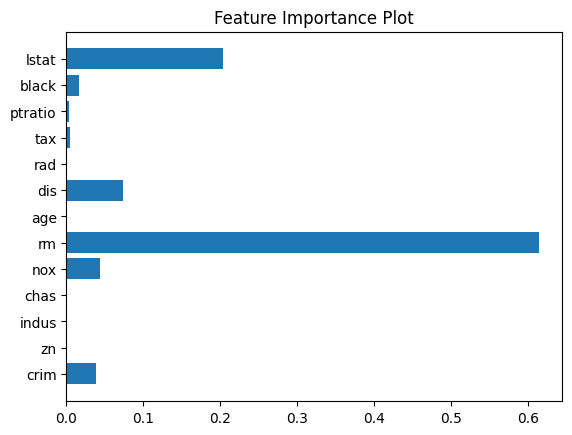

In [24]:

bm = DecisionTreeRegressor(  
                random_state=26,
                min_samples_leaf=1,
                min_samples_split=4,
                max_depth=5
            )


bm.fit(X,y)
plt.figure(figsize=(35, 15))

plot_tree(bm, feature_names = list(X.columns), filled = True, fontsize = 12)
plt.show()

df_imp = pd.DataFrame({'feature':X.columns,'importance':bm.feature_importances_})
plt.barh(df_imp['feature'],df_imp['importance'])
plt.title('Feature Importance Plot')
plt.show()